<a href="https://colab.research.google.com/github/kkwong5443/datasharing/blob/master/immune_clustering_with_categories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Immune Gene Clustering Notebook (With Category Annotation)
Fully annotated workflow including clustering and immune category labeling.

In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.patches as mpatches

## Load Data

In [4]:
file_path = 'immune101_immune related gene__matrix.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')
df.head()

,Name,Category,OAAMPJ,OAAMPE,OAAMPC,OAAMOV,OAAMOS,OAAMOP,OAAMOO,OAAMOE,OAAMNU,OAAMNI,OAAMND,OAAMNA
0,CD2,T-cell lineage & differentiation,2.444078,0.243633,2.091110,4.038092,0.000000,4.597691,1.721547,1.501044,2.888285,5.005410,2.395717,3.413666
1,CD3D,T-cell lineage & differentiation,2.884492,0.179499,0.958671,1.837156,0.000000,2.544328,0.235493,0.044586,2.011026,4.259826,0.908464,4.579221
2,CD3E,T-cell lineage & differentiation,4.483800,2.190093,1.617145,3.477121,2.303503,4.996958,3.088542,1.700924,3.212443,5.840845,1.870587,5.931442
3,CD3G,T-cell lineage & differentiation,3.561990,0.956767,0.797711,2.201448,0.000000,2.812477,1.153337,0.982030,0.967409,3.797857,1.706950,4.533707
4,CD4,T-cell lineage & differentiation,4.643700,4.430355,4.285358,4.300409,1.804488,5.593524,4.266125,3.237004,4.958804,6.227378,5.255723,5.679663


## Extract Expression Matrix

In [5]:
sample_cols = df.columns[2:]
X = df[sample_cols]
print(X.shape)

(101, 12)


## Sample Clustering (Ward's Method)

In [6]:
X_t = X.T
Z = linkage(X_t, method='ward')

## Dendrogram

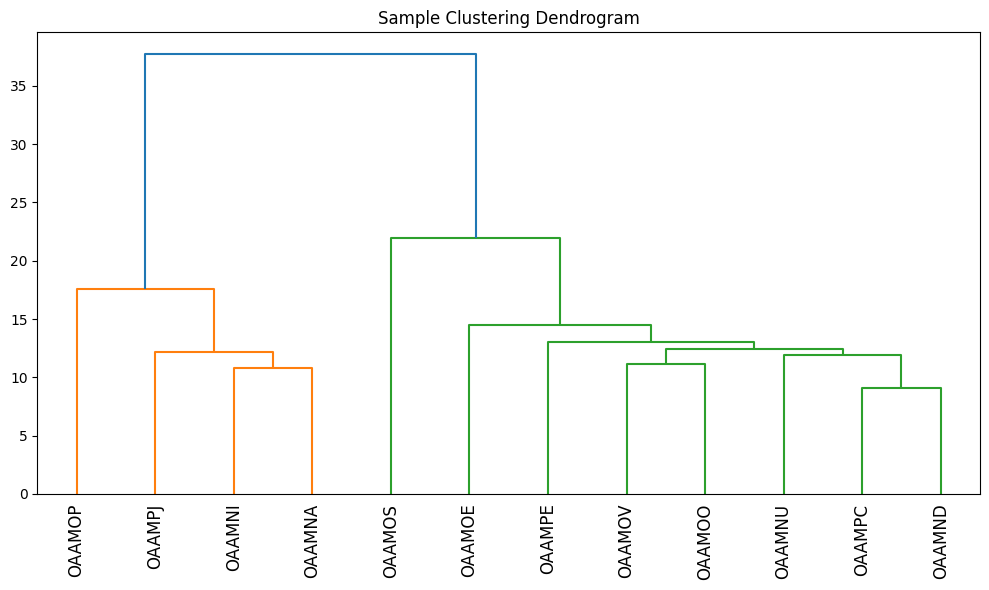

In [7]:
plt.figure(figsize=(10,6))
dendrogram(Z, labels=sample_cols, leaf_rotation=90)
plt.title('Sample Clustering Dendrogram')
plt.tight_layout()
plt.show()

## Select Top Variable Genes

In [8]:
top_idx = X.var(axis=1).sort_values(ascending=False).head(30).index
X_top = X.loc[top_idx]

## Z-score Normalization

In [9]:
X_scaled = (X_top - X_top.mean(axis=1).values.reshape(-1,1)) / X_top.std(axis=1).values.reshape(-1,1)

## Add Immune Category Annotation

In [10]:
categories = df.loc[top_idx, 'Category']
unique_cats = categories.unique()
palette = sns.color_palette('tab20', len(unique_cats))
cat_color_map = dict(zip(unique_cats, palette))
row_colors = categories.map(cat_color_map)

## Clustered Heatmap with Categories

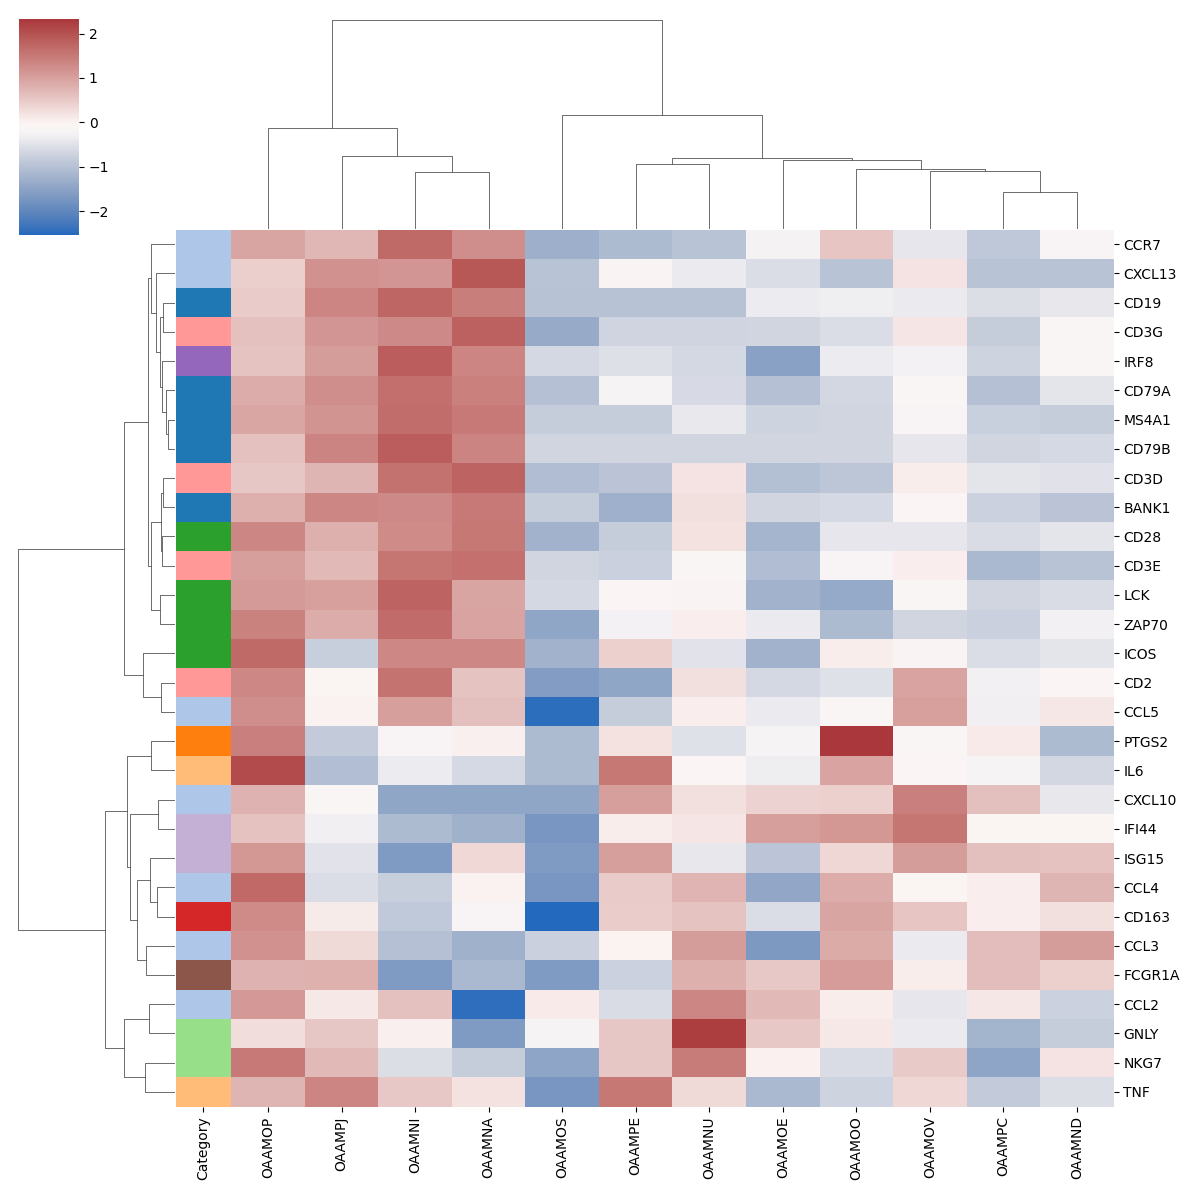

In [11]:
g = sns.clustermap(
    X_scaled,
    method='ward',
    metric='euclidean',
    cmap='vlag',
    figsize=(12,12),
    yticklabels=df.loc[top_idx,'Name'],
    xticklabels=sample_cols,
    row_colors=row_colors,
    dendrogram_ratio=(0.15,0.2),
    colors_ratio=0.05
)
plt.show()

## Category Legend

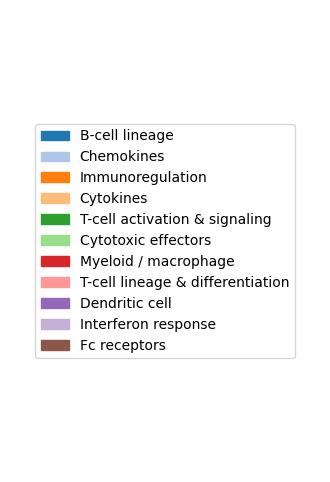

In [12]:
handles = [mpatches.Patch(color=cat_color_map[c], label=c) for c in unique_cats]
plt.figure(figsize=(4,6))
plt.legend(handles=handles, loc='center')
plt.axis('off')
plt.show()